<a href="https://colab.research.google.com/github/andrybrew/BDCBP-2-Python/blob/main/Text_Mining_Digital_Currency.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Text Mining**

### **Install and Load Packages**

In [ ]:
# Install packages
! pip install tweet-preprocessor
! pip install pyLDAvis

In [ ]:
# Load packages
import pandas as pd
import matplotlib.pyplot as plt
import preprocessor as p
import numpy as np
import networkx as nx
import wordcloud
import nltk
import warnings
import itertools
import re
import os
import random
import pyLDAvis
import pyLDAvis.sklearn 

ModuleNotFoundError: ignored

In [ ]:
# Import module
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
from wordcloud import STOPWORDS
from nltk.sentiment.vader import SentimentIntensityAnalyzer 
from tqdm import tqdm
from nltk import bigrams
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [ ]:
# Set parameter
warnings.filterwarnings('ignore')
pyLDAvis.enable_notebook()

### **Import Data**

In [ ]:
# Import data
df = pd.read_csv("https://raw.githubusercontent.com/apriandito/digital-currency/main/data/tweet_digitalcurrency_text-sample.csv")

In [ ]:
# Lihat 5 baris pertama data
df.head(5)

AttributeError: ignored

   created_at  ...                                               text
0  2020-12-30  ...  @LewisECFC @Kes1977 @herotroyippygod @GlobeSen...
1  2020-12-30  ...  @davidmcw Come on David, tell me billionaires ...
2  2020-12-30  ...  @PeterSchiff Chinas digital currency could bri...
3  2020-03-26  ...  @Bipoker @woofBIGDAWG @PeterSchiff Bitcoin is ...
4  2020-12-30  ...  @ecb @finanzfluss And people still call the NW...

[5 rows x 3 columns]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26768 entries, 0 to 26767
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   created_at   26768 non-null  object
 1   screen_name  26768 non-null  object
 2   text         26768 non-null  object
dtypes: object(3)
memory usage: 627.5+ KB


### **Text Preprocessing**

In [ ]:
# Pilih 5 kolom teks saja
tweet = df[['text']]

# Lihat 5 baris pertama data
tweet.head()

AttributeError: ignored

                                                text
0  @LewisECFC @Kes1977 @herotroyippygod @GlobeSen...
1  @davidmcw Come on David, tell me billionaires ...
2  @PeterSchiff Chinas digital currency could bri...
3  @Bipoker @woofBIGDAWG @PeterSchiff Bitcoin is ...
4  @ecb @finanzfluss And people still call the NW...

### **Transformation**

In [ ]:
# Membuat fungsi transformasi tweet
def transform_tweet(row):
  tweet = row['text']
  tweet = p.clean(tweet)
  tweet = str.lower(tweet)
  return tweet

In [ ]:
# Mengaplikasikan fungsi transofrmasi
tweet['transformed'] = tweet.apply(transform_tweet, axis=1)

# Lihat 5 baris pertama data
tweet.head(5)

AttributeError: ignored

                                                text                                        transformed
0  @LewisECFC @Kes1977 @herotroyippygod @GlobeSen...  much easier to implement the changes and laws ...
1  @davidmcw Come on David, tell me billionaires ...  come on david, tell me billionaires arent sitt...
2  @PeterSchiff Chinas digital currency could bri...  chinas digital currency could briefly become t...
3  @Bipoker @woofBIGDAWG @PeterSchiff Bitcoin is ...  bitcoin is already worthless, it wont suddenly...
4  @ecb @finanzfluss And people still call the NW...  and people still call the nwo and one digital ...

### **Tokenization**

In [ ]:
# Download Punkt
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
# Membuat fungsi tokenization
def tokenize_tweet(row):
    tweet = row['transformed']
    tokens = nltk.word_tokenize(tweet)
    token_words = [w for w in tokens if w.isalpha()]
    return token_words

In [ ]:
# Mengaplikasikan fungsi tokenization
tweet['tokenized'] = tweet.apply(tokenize_tweet, axis=1)

# Lihat 5 baris pertama data
tweet.head(5)

AttributeError: ignored

                                                text  ...                                          tokenized
0  @LewisECFC @Kes1977 @herotroyippygod @GlobeSen...  ...  [much, easier, to, implement, the, changes, an...
1  @davidmcw Come on David, tell me billionaires ...  ...  [come, on, david, tell, me, billionaires, aren...
2  @PeterSchiff Chinas digital currency could bri...  ...  [chinas, digital, currency, could, briefly, be...
3  @Bipoker @woofBIGDAWG @PeterSchiff Bitcoin is ...  ...  [bitcoin, is, already, worthless, it, wont, su...
4  @ecb @finanzfluss And people still call the NW...  ...  [and, people, still, call, the, nwo, and, one,...

[5 rows x 3 columns]

### **Lemmatization**

In [ ]:
# Download Wordnet
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
# Membuat fungsi lemmatization
def lemmatize_tweet(row):
    list = row['tokenized']
    lemmatize_list = [WordNetLemmatizer().lemmatize(w, pos='v') for w in list]
    return(lemmatize_list)

In [ ]:
# Mengaplikasikan fungsi lemmatization
tweet['lemmatized'] = tweet.apply(lemmatize_tweet, axis=1)

# Lihat 5 baris pertama data
tweet.head(5)

AttributeError: ignored

                                                text  ...                                         lemmatized
0  @LewisECFC @Kes1977 @herotroyippygod @GlobeSen...  ...  [much, easier, to, implement, the, change, and...
1  @davidmcw Come on David, tell me billionaires ...  ...  [come, on, david, tell, me, billionaires, aren...
2  @PeterSchiff Chinas digital currency could bri...  ...  [chinas, digital, currency, could, briefly, be...
3  @Bipoker @woofBIGDAWG @PeterSchiff Bitcoin is ...  ...  [bitcoin, be, already, worthless, it, wont, su...
4  @ecb @finanzfluss And people still call the NW...  ...  [and, people, still, call, the, nwo, and, one,...

[5 rows x 4 columns]

### **Stopword Removal**

In [ ]:
# Download stopword bahasa inggris
nltk.download('stopwords')
stops = set(stopwords.words("english"))     

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# Membuat fungsi lemmatization
def stopword_tweet(row):
    list = row['lemmatized']
    stopword_list = [w for w in list if not w in stops]
    return(stopword_list)

In [ ]:
# Mengaplikasikan fungsi Stopword
tweet['stopword'] = tweet.apply(stopword_tweet, axis=1)

# Lihat 5 baris pertama data
tweet.head(5)

AttributeError: ignored

                                                text  ...                                           stopword
0  @LewisECFC @Kes1977 @herotroyippygod @GlobeSen...  ...  [much, easier, implement, change, laws, theyve...
1  @davidmcw Come on David, tell me billionaires ...  ...  [come, david, tell, billionaires, arent, sit, ...
2  @PeterSchiff Chinas digital currency could bri...  ...  [chinas, digital, currency, could, briefly, be...
3  @Bipoker @woofBIGDAWG @PeterSchiff Bitcoin is ...  ...  [bitcoin, already, worthless, wont, suddenly, ...
4  @ecb @finanzfluss And people still call the NW...  ...  [people, still, call, nwo, one, digital, curre...

[5 rows x 5 columns]

### **Rejoin**

In [ ]:
# Membuat fungsi rejoin
def rejoin_tweet(row):
    list = row['stopword']
    joined_words = ( " ".join(list))
    return joined_words

In [ ]:
# Mengaplikasikan fungsi rejoin
tweet['final'] = tweet.apply(rejoin_tweet, axis=1)

# Lihat 5 baris pertama data
tweet.head(5)

AttributeError: ignored

                                                text  ...                                              final
0  @LewisECFC @Kes1977 @herotroyippygod @GlobeSen...  ...  much easier implement change laws theyve want ...
1  @davidmcw Come on David, tell me billionaires ...  ...  come david tell billionaires arent sit hot tub...
2  @PeterSchiff Chinas digital currency could bri...  ...  chinas digital currency could briefly become w...
3  @Bipoker @woofBIGDAWG @PeterSchiff Bitcoin is ...  ...  bitcoin already worthless wont suddenly become...
4  @ecb @finanzfluss And people still call the NW...  ...  people still call nwo one digital currency con...

[5 rows x 6 columns]

In [ ]:
# Final tweet yang sudah di proses
tweet_clean = tweet[['final']]
tweet_clean = tweet_clean.rename(columns={'final': 'text'})

# Lihat 5 baris pertama data
tweet_clean.head(5)

AttributeError: ignored

                                                text
0  much easier implement change laws theyve want ...
1  come david tell billionaires arent sit hot tub...
2  chinas digital currency could briefly become w...
3  bitcoin already worthless wont suddenly become...
4  people still call nwo one digital currency con...

### **Wordcloud**

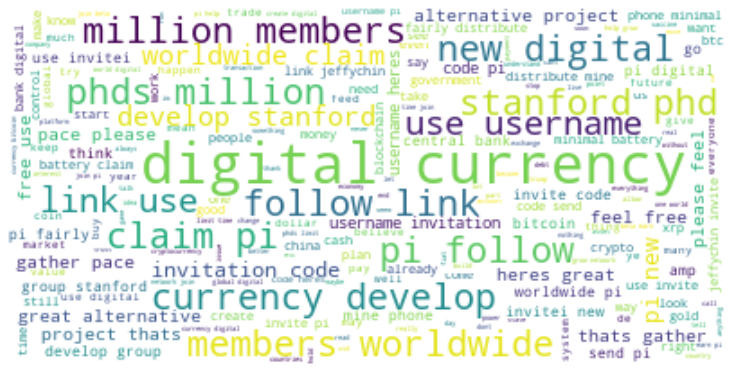

In [ ]:
# Visualisasi Word Cloud
text_wordcloud = " ".join(tweet for tweet in tweet_clean.text)

cloud = WordCloud(background_color='white').generate(text_wordcloud)

plt.figure(figsize=(10, 10), facecolor=None)
plt.imshow(cloud, interpolation="bilinear")
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

### **Sentiment Analysis**

In [ ]:
# Download corpus untuk sentiment analysis
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [ ]:
# Sentiment Analysis
sid = SentimentIntensityAnalyzer()
listy = [] 
for index, row in tweet_clean.iterrows():
  ss = sid.polarity_scores(row['text'])
  listy.append(ss)
  
se = pd.Series(listy)
tweet_clean['polarity'] = se.values
display(tweet_clean.head(5))

AttributeError: ignored

                                                text                                           polarity
0  much easier implement change laws theyve want ...  {'neg': 0.0, 'neu': 0.673, 'pos': 0.327, 'comp...
1  come david tell billionaires arent sit hot tub...  {'neg': 0.0, 'neu': 0.736, 'pos': 0.264, 'comp...
2  chinas digital currency could briefly become w...  {'neg': 0.199, 'neu': 0.623, 'pos': 0.178, 'co...
3  bitcoin already worthless wont suddenly become...  {'neg': 0.433, 'neu': 0.567, 'pos': 0.0, 'comp...
4  people still call nwo one digital currency con...  {'neg': 0.327, 'neu': 0.673, 'pos': 0.0, 'comp...

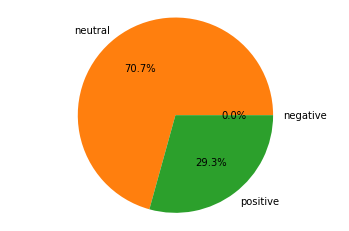

In [ ]:
# Visualisasi Pie Chart
labels = ['negative', 'neutral', 'positive']
sizes  = [ss['neg'], ss['neu'], ss['pos']]
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.axis('equal') 
plt.show()

### **Topic Modelling**

In [ ]:
# clone tambahan library dari github
! git clone https://github.com/machine-learning-ss/tm

# Set Data Directory
os.chdir('tm')

Cloning into 'tm'...
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 7 (delta 0), reused 0 (delta 0), pack-reused 0
Unpacking objects: 100% (7/7), done.


In [ ]:
import MyLib as TS

Tweets = tweet_clean['text']
print('Total loaded tweets = {0}'.format(len(Tweets)))

Total loaded tweets = 26768


In [ ]:
n_topics = 4
top_topics = 4
top_words = 10

In [ ]:
# Feature Extraction
count_vector = CountVectorizer(token_pattern = r'\b[a-zA-Z]{3,}\b') 
dtm_tf = count_vector.fit_transform(Tweets)
tf_terms = count_vector.get_feature_names()

100%|██████████| 26768/26768 [00:00<00:00, 659007.49it/s]


In total there are 4 major topics, distributed as follows


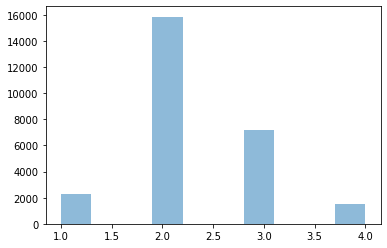

Printing top 4 Topics, with top 10 Words:
Topic #0:
digital currency first earn blockchain help grow app company base
Topic #1:
digital currency bank world bitcoin use central like money get
Topic #2:
use currency link digital follow develop stanford phds million worldwide
Topic #3:
que order amp great community lol twitter mark research name


In [ ]:
# Fungsi untuk mencari topic
lda_tf = LatentDirichletAllocation(n_components=n_topics, learning_method='online', random_state=0).fit(dtm_tf)

# Menampilkan Topik
vsm_topics = lda_tf.transform(dtm_tf); doc_topic =  [a.argmax()+1 for a in tqdm(vsm_topics)] # topic of docs
print('In total there are {0} major topics, distributed as follows'.format(len(set(doc_topic))))
plt.hist(np.array(doc_topic), alpha=0.5); plt.show()
print('Printing top {0} Topics, with top {1} Words:'.format(top_topics, top_words))
TS.print_Topics(lda_tf, tf_terms, top_topics, top_words)

In [ ]:
# Visualisasi Topic Secara Interaktif
pyLDAvis.sklearn.prepare(lda_tf, dtm_tf, count_vector) 

ImportError: ignored

### **Text Network Analysis**

In [ ]:
# Pilih teks
text = tweet_clean['text']
text

In [ ]:
# Tokenize
text_data = [word_tokenize(i) for i in text]
print(text_data)

In [ ]:
# Membuat fungsi cooccurence
def generate_co_occurrence_matrix(corpus):
    vocab = set(corpus)
    vocab = list(vocab)
    vocab_index = {word: i for i, word in enumerate(vocab)}

    bi_grams = list(bigrams(corpus))
    bigram_freq = nltk.FreqDist(bi_grams).most_common(len(bi_grams))
 
    co_occurrence_matrix = np.zeros((len(vocab), len(vocab)))
 
    for bigram in bigram_freq:
        current = bigram[0][1]
        previous = bigram[0][0]
        count = bigram[1]
        pos_current = vocab_index[current]
        pos_previous = vocab_index[previous]
        co_occurrence_matrix[pos_current][pos_previous] = count
    co_occurrence_matrix = np.matrix(co_occurrence_matrix)
 
    return co_occurrence_matrix, vocab_index

In [ ]:
# Membuat Adjacency Matrix
data = list(itertools.chain.from_iterable(text_data))
matrix, vocab_index = generate_co_occurrence_matrix(data)
 
 
data_matrix = pd.DataFrame(matrix, index=vocab_index,
                             columns=vocab_index)

# Show Adjacency Matrix
data_matrix.head()

In [ ]:
# Membuat Network dengan Adjacency Matrix
G = nx.from_pandas_adjacency(data_matrix)

In [ ]:
# Degree Centrality
degree = nx.degree_centrality(G)

list_node = list(degree) 
selected_node = list_node[1:600]

In [ ]:
sampled_graph = G.subgraph(selected_node)

plt.figure(figsize=(10, 10), facecolor=None)
nx.draw(sampled_graph, with_labels=True, 
        node_color='skyblue', node_size=600, 
        arrowstyle='->',arrowsize=20, edge_color='r',
        font_size=7,
        pos=nx.kamada_kawai_layout(sampled_graph))